### Importy


In [13]:
# !git clone https://github.com/facebookresearch/segment-anything.git
# !git clone https://github.com/IDEA-Research/groundingdino.git
# !git clone https://github.com/IDEA-Research/Grounded-Segment-Anything.git

# %cd /content/groundingdino
# !pip install -r requirements.txt

# %cd /content/segment-anything
# !pip install -r requirements.txt

# %cd /content/Grounded-Segment-Anything
# !pip install -r requirements.txt


In [2]:
!pip install -q rembg
!pip install -q onnxruntime
from rembg import remove


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement on

In [3]:
#!pip uninstall -y pillow torchvision torch

In [4]:
#!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu130

In [14]:
import sys

# sys.path.extend([
#     "/content/segment-anything",
#     "/content/groundingdino",
#     "/content/Grounded-Segment-Anything",
# ])

from pathlib import Path
import zipfile
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights, efficientnet_b0, EfficientNet_B0_Weights, mobilenet_v3_large, MobileNet_V3_Large_Weights

from PIL import Image
import numpy as np
import pickle

import matplotlib.pyplot as plt

# from google.colab import files
# from google.colab import drive



In [6]:
#!ls /content/Grounded-Segment-Anything

### Wczytywanie i przygotowanie danych

In [7]:
# drive.mount('/content/drive')


In [15]:
class ImageNet32Dataset(Dataset):
    def __init__(self, data_file, transform=None):
        self.transform = transform

        # Wczytaj plik val_data
        print(f"Ładowanie pliku: {data_file}")
        with open(data_file, 'rb') as fo:
            data_dict = pickle.load(fo)

        # Klucze są stringami
        self.data = data_dict['data']
        self.labels = data_dict['labels']

        print(f"Oryginalny kształt danych: {self.data.shape}")
        print(f"Liczba etykiet: {len(self.labels)}")

        # Konwersja danych do odpowiedniego formatu
        # data ma format: samples x 3072 (32x32x3)
        self.data = self.data.reshape(-1, 3, 32, 32)
        # Transpozycja do formatu HWC dla PIL (batch, height, width, channels)
        self.data = self.data.transpose(0, 2, 3, 1)

        # Labels są indeksowane od 1, zmień na 0-999
        self.labels = [label - 1 for label in self.labels]

        print(f"Załadowano {len(self.labels)} obrazów")
        print(f"Zakres etykiet: {min(self.labels)} - {max(self.labels)}")
        print(f"Kształt po transformacji: {self.data.shape}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.data[idx]
        label = self.labels[idx]

        # Konwersja do PIL Image
        img = Image.fromarray(img.astype('uint8'))

        if self.transform:
            img = self.transform(img)

        return img, label

In [18]:
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision.datasets import ImageFolder

class ImageNetValDataset(Dataset):
    def __init__(self, val_dir, labels_file, transform=None):
        self.val_dir = Path(val_dir)
        self.transform = transform

        with open(labels_file) as f:
            self.labels = [int(x.strip()) - 1 for x in f]

        self.images = sorted(self.val_dir.glob("*.JPEG"))
        assert len(self.images) == len(self.labels)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


In [19]:
data_file = "val_blurred"
batch_size = 64

#Transformacje obrazu
#ResNet18_Weights.DEFAULT.transforms() = EfficientNet_B0_Weights.DEFAULT.transforms() = ImageClassification(
#     crop_size=[224]
#     resize_size=[256]
#     mean=[0.485, 0.456, 0.406]
#     std=[0.229, 0.224, 0.225]
#     interpolation=InterpolationMode.BILINEAR
# )
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

#dataset = ImageNet32Dataset(data_file, transform=transform)
dataset = ImageFolder(
    root=data_file,
    transform=transform
)
#dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)


#Mapowanie klas ImageNet do cat/dog
#https://deeplearning.cms.waikato.ac.nz/user-guide/class-maps/IMAGENET/



In [20]:
from collections import defaultdict
from torch.utils.data import Subset
import random

NUM_CLASSES = 100
random.seed(42)

class_to_indices = defaultdict(list)

# zbierz indeksy per klasa
for idx in range(len(dataset)):
    _, label = dataset[idx]
    class_to_indices[label].append(idx)

# losuj po 1 obrazie z różnych klas
selected_indices = []
all_classes = list(class_to_indices.keys())
random.shuffle(all_classes)

for cls in all_classes[:NUM_CLASSES]:
    selected_indices.append(random.choice(class_to_indices[cls]))

subset_dataset = Subset(dataset, selected_indices)

dataloader = DataLoader(
    subset_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Utworzono subset: {len(subset_dataset)} obrazów, {NUM_CLASSES} klas")


Utworzono subset: 100 obrazów, 100 klas


In [21]:
img, label = dataset[0]
print(img.shape)
print(label)


torch.Size([3, 224, 224])
0


### Przygotowanie danyc

### implementacje Occlusion i inne pomocnicze

In [23]:
def apply_occlusion_square(image: torch.Tensor, occlusion_percent: float = 20, top: int = None,
                    left: int = None) -> torch.Tensor:
    c, h, w = image.shape
    occ_h = int(h * occlusion_percent / 100)
    occ_w = int(w * occlusion_percent / 100)

    if top is None:
        top = (h - occ_h) // 2
    if left is None:
        left = (w - occ_w) // 2

    occluded = image.clone()
    occluded[:, top:top + occ_h, left:left + occ_w] = 0  #black square

    return occluded



def apply_background_removal(image: torch.Tensor, device='cuda') -> torch.Tensor:
    try:
        # Denormalizacja obrazu do PIL
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img_denorm = image * std + mean
        img_denorm = torch.clamp(img_denorm, 0, 1)

        # Konwersja do PIL Image (RGB)
        img_np = (img_denorm.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        img_pil = Image.fromarray(img_np)

        # Usunięcie tła za pomocą rembg (zwraca obraz RGBA)
        output = remove(img_pil)

        # Konwersja RGBA do RGB z czarnym tłem
        output_rgb = Image.new("RGB", output.size, (0, 0, 0))
        output_rgb.paste(output, mask=output.split()[3])  # Użyj alpha channel jako maski

        # Konwersja z powrotem do tensora
        img_array = np.array(output_rgb).astype(np.float32) / 255.0
        img_tensor = torch.from_numpy(img_array).permute(2, 0, 1)

        # Renormalizacja
        img_normalized = (img_tensor - mean) / std

        return img_normalized.to(device)

    except Exception as e:
        print(f"Błąd usuwania tła: {e}, zwracam oryginalny obraz")
        return image


# def predict_cat_dog(outputs):
#     probs = torch.nn.functional.softmax(outputs, dim=1)
#     top_idx = torch.argmax(probs, dim=1)
#     predictions = []
#     for idx in top_idx:
#         if idx.item() == cat_index:
#             predictions.append("cat")
#         elif idx.item() == dog_index:
#             predictions.append("dog")
#         else:
#             predictions.append("other")
#     return predictions


def compute_accuracy(model, dataloader, occlusion_type="square", occlusion_percent=20, device='cuda'):
    correct = 0
    total = 0
    top5_correct = 0

    for images, labels in dataloader:
        if occlusion_type == "square":
            images = torch.stack([apply_occlusion_square(img, occlusion_percent=occlusion_percent) for img in images])
        elif occlusion_type == "background_removal":
            images = torch.stack([apply_background_removal(img, device) for img in images])

        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs = model(images)

        # Top-1 accuracy
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()

        # Top-5 accuracy
        _, top5_pred = outputs.topk(5, 1, True, True)
        top5_correct += top5_pred.eq(labels.view(-1, 1).expand_as(top5_pred)).sum().item()

        total += labels.size(0)

    top1_acc = correct / total
    top5_acc = top5_correct / total
    return top1_acc, top5_acc


Wizualizacja przykładowych obrazów

Zbieranie obrazów z dataloadera...
Zebrano 100 obrazów
Przygotowywanie okluzji...
Usuwanie tła (może trochę potrwać)...
Tworzenie wykresów...


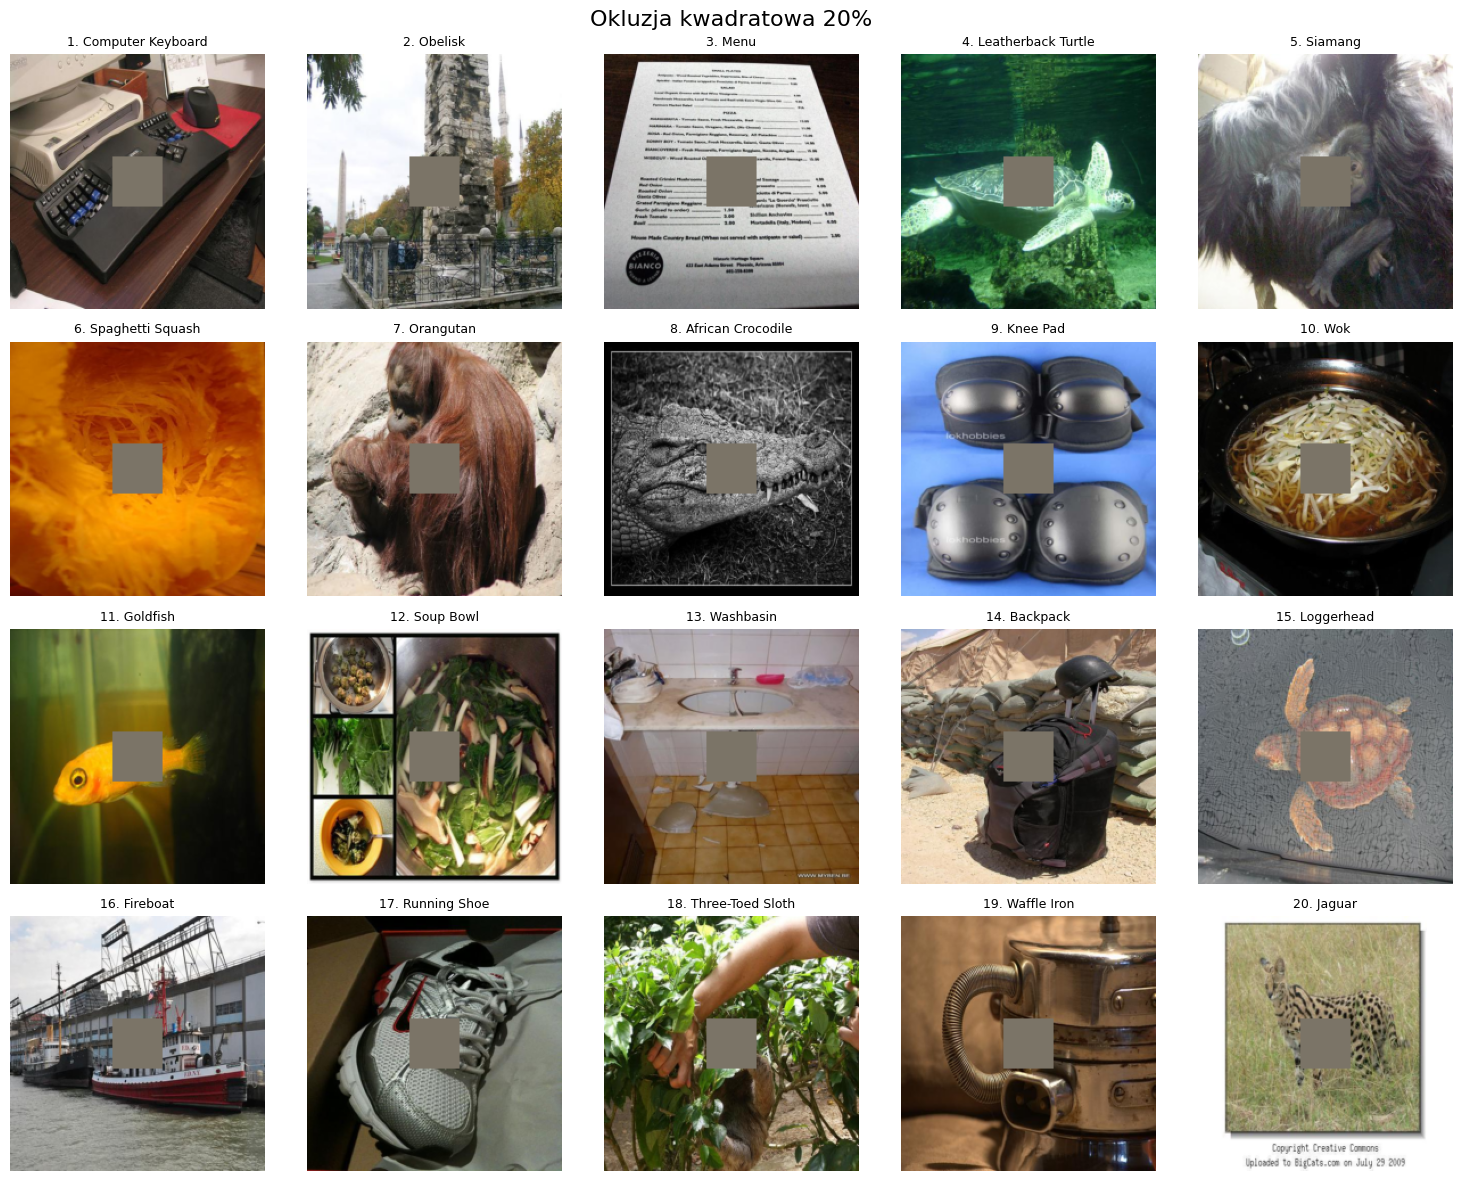

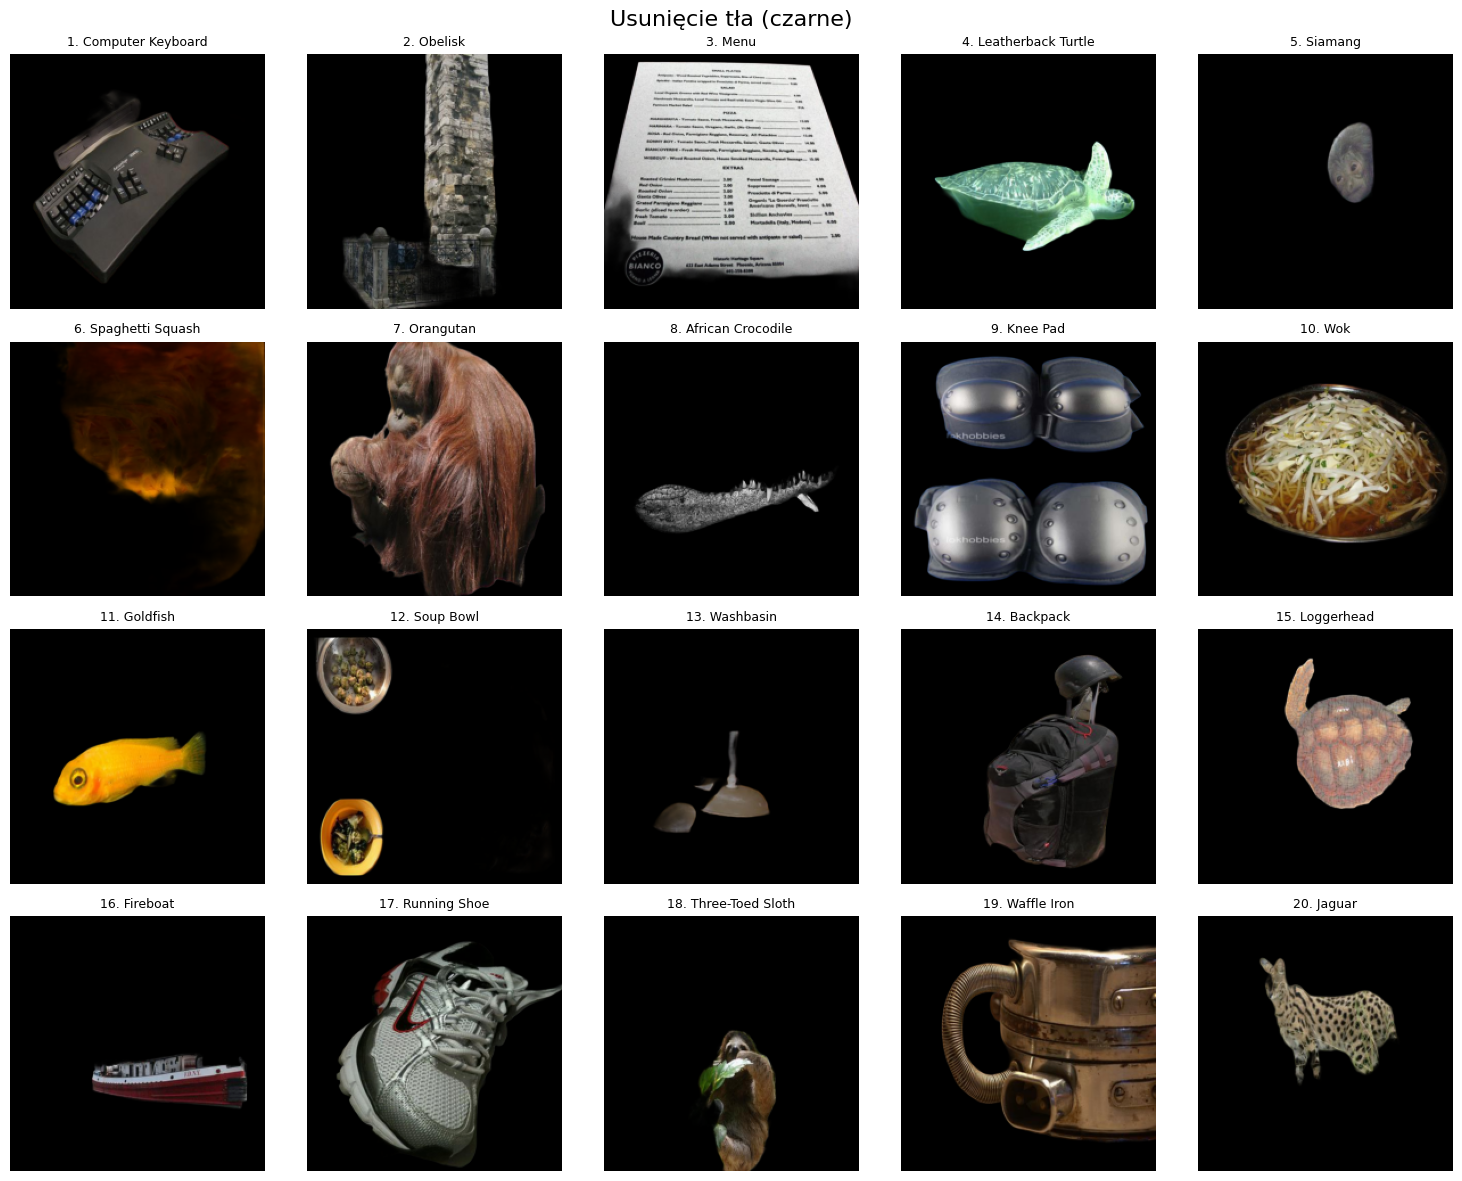

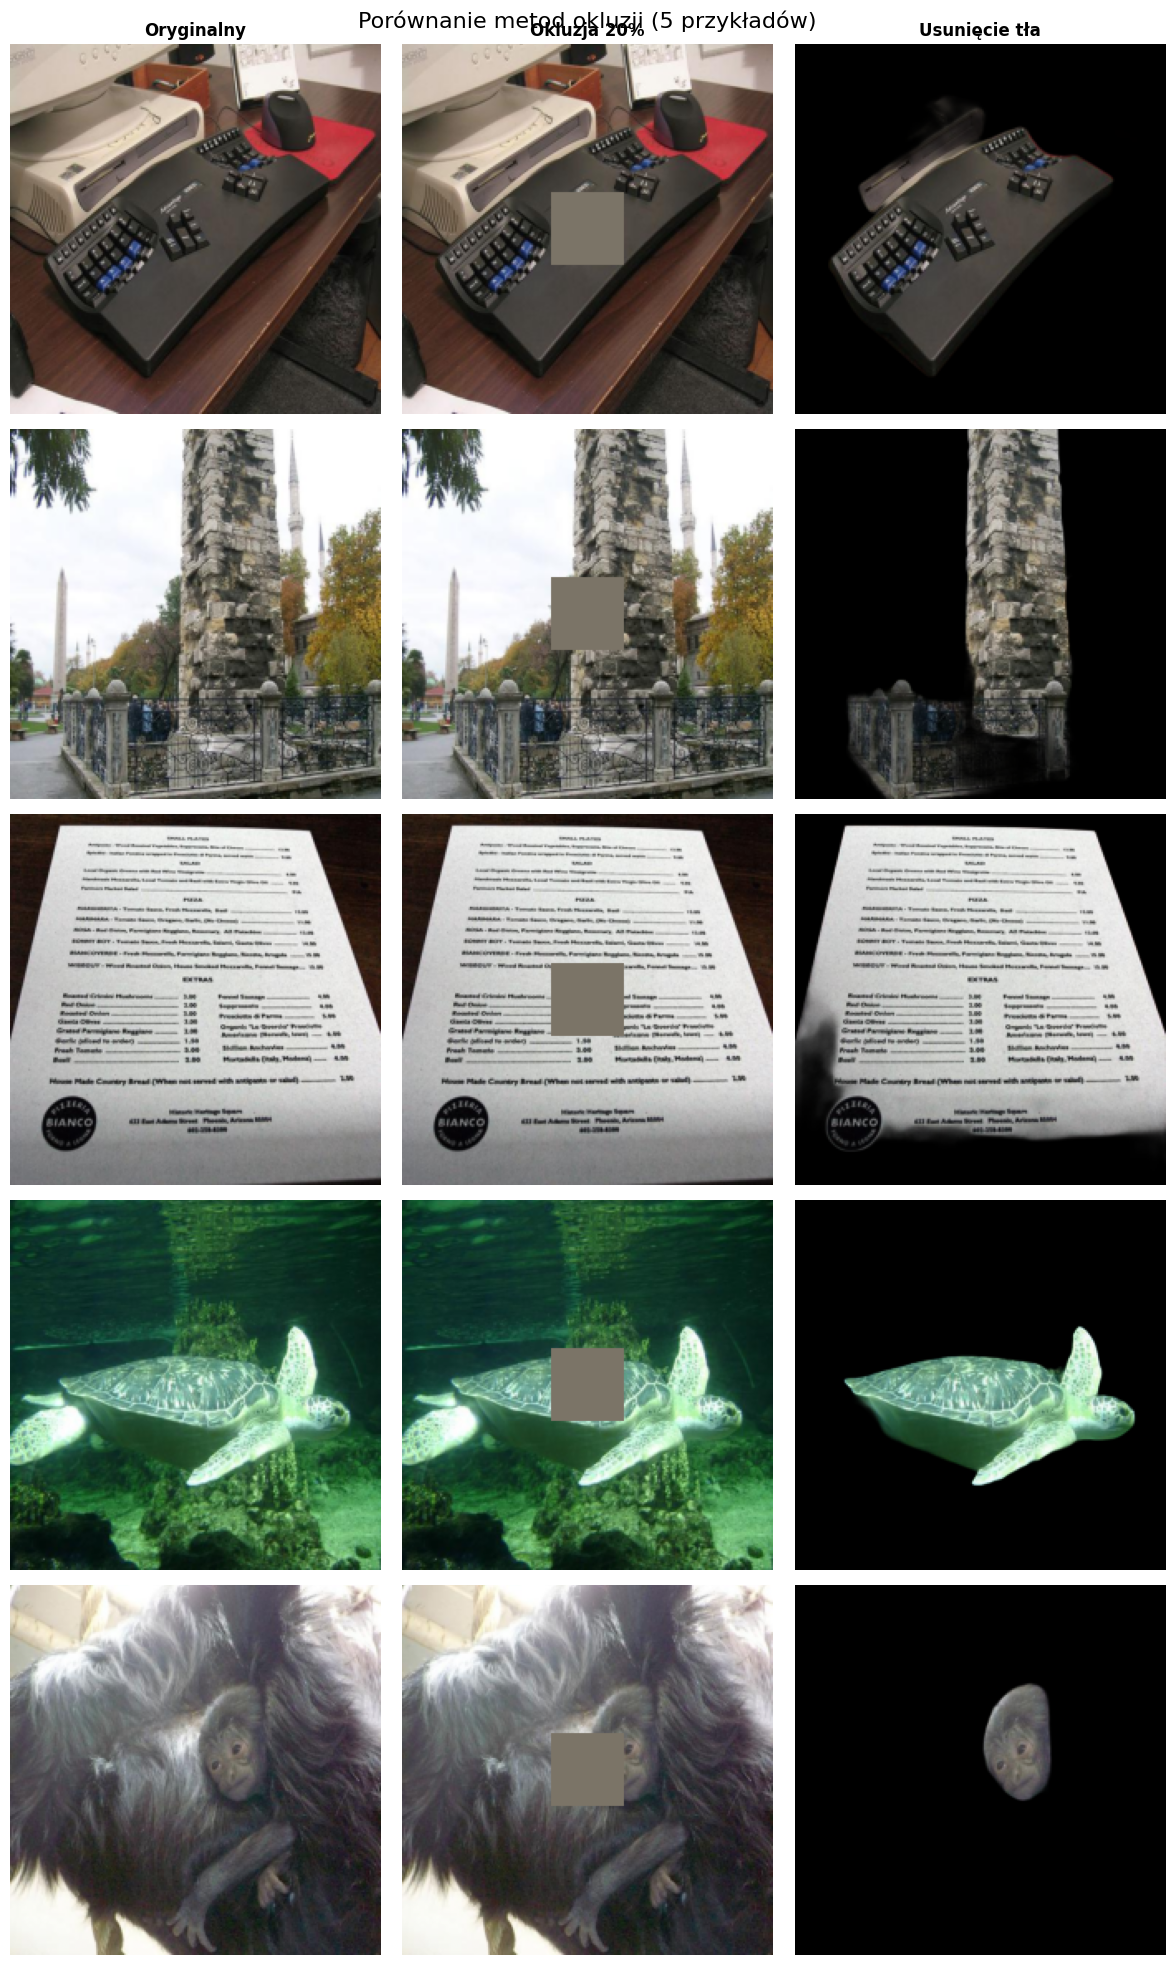


=== Wybrane klasy do wizualizacji ===
1. Computer Keyboard
2. Obelisk
3. Menu
4. Leatherback Turtle
5. Siamang
6. Spaghetti Squash
7. Orangutan
8. African Crocodile
9. Knee Pad
10. Wok
11. Goldfish
12. Soup Bowl
13. Washbasin
14. Backpack
15. Loggerhead
16. Fireboat
17. Running Shoe
18. Three-Toed Sloth
19. Waffle Iron
20. Jaguar


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Najpierw potrzebujemy mapowania indeksów do nazw klas ImageNet
# Możesz pobrać plik z nazwami klas lub użyć wbudowanego z torchvision

# Opcja 1: Użyj nazw z modelu (najprostsze)
def get_class_name(label_idx):
    """Zwraca nazwę klasy dla danego indeksu"""
    # Możesz użyć nazw z ResNet weights
    class_names = ResNet18_Weights.DEFAULT.meta["categories"]
    return class_names[label_idx]

# Opcja 2: Jeśli chcesz bardziej czytelne nazwy, możesz je uprościć
def get_simple_class_name(label_idx):
    """Zwraca uproszczoną nazwę klasy"""
    full_name = get_class_name(label_idx)
    # ImageNet często ma formaty jak "Egyptian_cat, tabby_cat" - weź pierwszą nazwę
    return full_name.split(',')[0].replace('_', ' ').title()


def denormalize_image(image):
    device = image.device
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)
    img_denorm = image * std + mean
    img_denorm = torch.clamp(img_denorm, 0, 1)
    return img_denorm.permute(1, 2, 0).cpu().numpy()

# Zbierz wszystkie obrazy do jednej listy
print("Zbieranie obrazów z dataloadera...")
all_images = []
all_labels = []
for images, labels in dataloader:
    all_images.append(images)
    all_labels.append(labels)
all_images = torch.cat(all_images, dim=0)
all_labels = torch.cat(all_labels, dim=0)
print(f"Zebrano {len(all_images)} obrazów")

# Losowy wybór 20 obrazów
import random
random.seed(42)
indices = random.sample(range(len(all_images)), 20)

# Przygotuj obrazy z różnymi okluzjami
print("Przygotowywanie okluzji...")
original_images = [all_images[i] for i in indices]
occluded_20_images = [apply_occlusion_square(all_images[i], occlusion_percent=20) for i in indices]
print("Usuwanie tła (może trochę potrwać)...")
bg_removed_images = [apply_background_removal(all_images[i], device) for i in indices]
labels_selected = [all_labels[i].item() for i in indices]

# Wykres 1: Okluzja kwadratowa 20%
print("Tworzenie wykresów...")
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Okluzja kwadratowa 20%', fontsize=16)

for idx, (ax, img, label) in enumerate(zip(axes.flat, occluded_20_images, labels_selected)):
    img_display = denormalize_image(img)
    ax.imshow(img_display)
    ax.axis('off')
    label_name = get_simple_class_name(label)
    ax.set_title(f'{idx+1}. {label_name}', fontsize=9)

plt.tight_layout()
plt.show()

# Wykres 2: Usunięcie tła
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
fig.suptitle('Usunięcie tła (czarne)', fontsize=16)

for idx, (ax, img, label) in enumerate(zip(axes.flat, bg_removed_images, labels_selected)):
    img_display = denormalize_image(img)
    ax.imshow(img_display)
    ax.axis('off')
    label_name = get_simple_class_name(label)
    ax.set_title(f'{idx+1}. {label_name}', fontsize=9)

plt.tight_layout()
plt.show()

# Wykres 3: Porównanie obok siebie (5 przykładów)
fig, axes = plt.subplots(5, 3, figsize=(12, 20))
fig.suptitle('Porównanie metod okluzji (5 przykładów)', fontsize=16)

for row in range(5):
    label_name = get_simple_class_name(labels_selected[row])

    # Oryginalny
    img_display = denormalize_image(original_images[row])
    axes[row, 0].imshow(img_display)
    axes[row, 0].axis('off')
    if row == 0:
        axes[row, 0].set_title('Oryginalny', fontsize=12, fontweight='bold')
    axes[row, 0].set_ylabel(f'{label_name}', fontsize=10, fontweight='bold')

    # Okluzja 20%
    img_display = denormalize_image(occluded_20_images[row])
    axes[row, 1].imshow(img_display)
    axes[row, 1].axis('off')
    if row == 0:
        axes[row, 1].set_title('Okluzja 20%', fontsize=12, fontweight='bold')

    # Usunięcie tła
    img_display = denormalize_image(bg_removed_images[row])
    axes[row, 2].imshow(img_display)
    axes[row, 2].axis('off')
    if row == 0:
        axes[row, 2].set_title('Usunięcie tła', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# BONUS: Wykres pokazujący różnorodność klas
print("\n=== Wybrane klasy do wizualizacji ===")
for idx, label in enumerate(labels_selected[:20]):
    print(f"{idx+1}. {get_simple_class_name(label)}")


### Ewaluacja


=== TEST 1: Okluzja kwadratowa ===
Okluzja 0% -> ResNet: 0.7100, EfficientNet: 0.7500, MobileNet: 0.7400
Okluzja 5% -> ResNet: 0.6900, EfficientNet: 0.7400, MobileNet: 0.7400
Okluzja 10% -> ResNet: 0.6600, EfficientNet: 0.7400, MobileNet: 0.7500
Okluzja 15% -> ResNet: 0.6200, EfficientNet: 0.7100, MobileNet: 0.7500
Okluzja 20% -> ResNet: 0.6000, EfficientNet: 0.7400, MobileNet: 0.7400
Okluzja 25% -> ResNet: 0.5400, EfficientNet: 0.7200, MobileNet: 0.7100
Okluzja 30% -> ResNet: 0.5000, EfficientNet: 0.7200, MobileNet: 0.6700
Okluzja 35% -> ResNet: 0.4400, EfficientNet: 0.7200, MobileNet: 0.6900
Okluzja 40% -> ResNet: 0.4100, EfficientNet: 0.7100, MobileNet: 0.6600
Okluzja 45% -> ResNet: 0.3900, EfficientNet: 0.6700, MobileNet: 0.6200
Okluzja 50% -> ResNet: 0.3200, EfficientNet: 0.6100, MobileNet: 0.5900
Okluzja 55% -> ResNet: 0.2500, EfficientNet: 0.5900, MobileNet: 0.5500
Okluzja 60% -> ResNet: 0.1500, EfficientNet: 0.4900, MobileNet: 0.5300
Okluzja 65% -> ResNet: 0.1100, EfficientNet

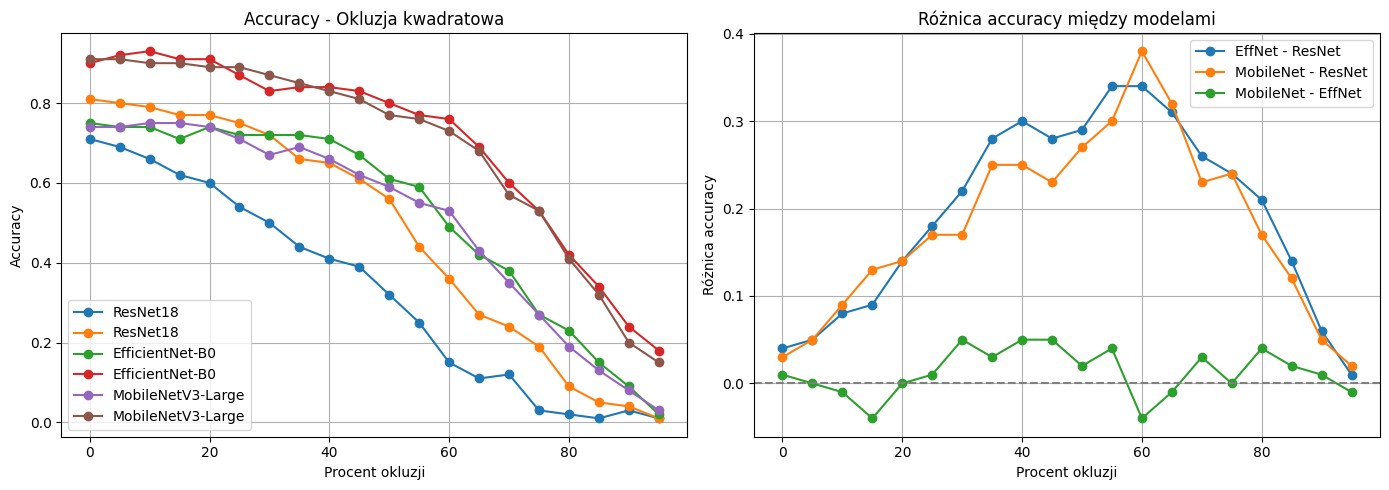

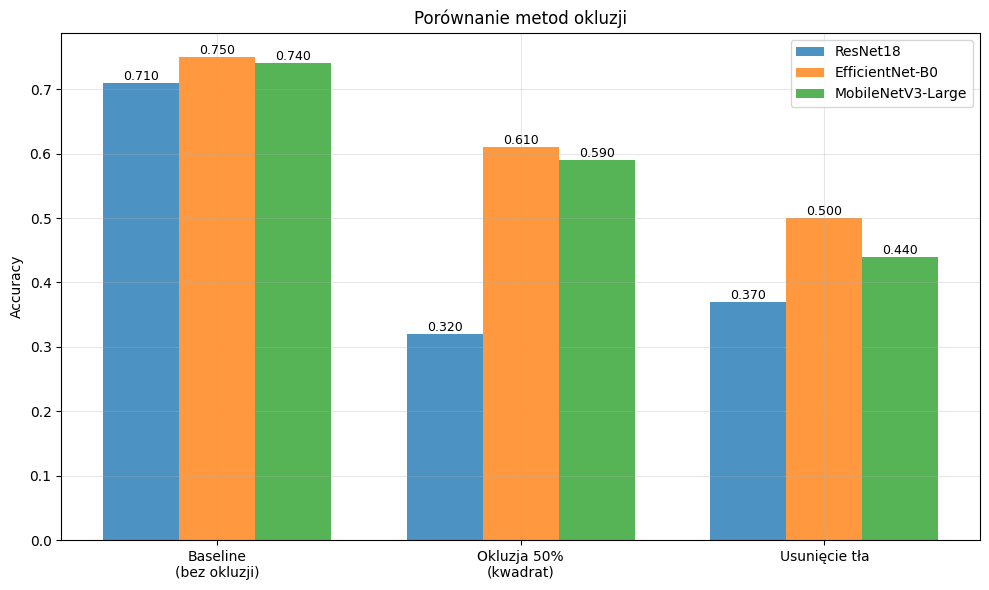


=== PODSUMOWANIE ===
Baseline (bez okluzji):
  ResNet: 0.7100, EfficientNet: 0.7500, MobileNet: 0.7400

Okluzja kwadratowa 50%:
  ResNet: 0.3200, EfficientNet: 0.6100, MobileNet: 0.5900

Usunięcie tła (czarne):
  ResNet: 0.3700, EfficientNet: 0.5000, MobileNet: 0.4400


In [30]:

#Wczytanie modeli
model_resnet = resnet18(weights=ResNet18_Weights.DEFAULT).to(device)
model_resnet.eval()

model_efficientnet = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT).to(device)
model_efficientnet.eval()

model_mobilenet = mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.DEFAULT).to(device)
model_mobilenet.eval()

# Test 1: Okluzja kwadratowa
print("\n=== TEST 1: Okluzja kwadratowa ===")
occlusion_levels = list(range(0, 100, 5))
resnet_acc_square = []
effnet_acc_square = []
mobilenet_acc_square = []

for occ in occlusion_levels:
    acc_r = compute_accuracy(model_resnet, dataloader, occlusion_type="square", occlusion_percent=occ)
    acc_e = compute_accuracy(model_efficientnet, dataloader, occlusion_type="square", occlusion_percent=occ)
    acc_m = compute_accuracy(model_mobilenet, dataloader, occlusion_type="square", occlusion_percent=occ)
    resnet_acc_square.append(acc_r)
    effnet_acc_square.append(acc_e)
    mobilenet_acc_square.append(acc_m)
    print(f"Okluzja {occ}% -> ResNet: {acc_r[0]:.4f}, EfficientNet: {acc_e[0]:.4f}, MobileNet: {acc_m[0]:.4f}")

# Test 2: Usunięcie tła (czarne tło)
print("\n=== TEST 2: Usunięcie tła  ===")
acc_r = compute_accuracy(model_resnet, dataloader, occlusion_type="background_removal")
acc_e = compute_accuracy(model_efficientnet, dataloader, occlusion_type="background_removal")
acc_m = compute_accuracy(model_mobilenet, dataloader, occlusion_type="background_removal")
resnet_acc_bg = acc_r
effnet_acc_bg = acc_e
mobilenet_acc_bg = acc_m
print(f"Czarne tło -> ResNet: {acc_r[0]:.4f}, EfficientNet: {acc_e[0]:.4f}, MobileNet: {acc_m[0]:.4f}")

# Wykresy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres 1: Okluzja kwadratowa
axes[0].plot(occlusion_levels, resnet_acc_square, marker='o', label='ResNet18')
axes[0].plot(occlusion_levels, effnet_acc_square, marker='o', label='EfficientNet-B0')
axes[0].plot(occlusion_levels, mobilenet_acc_square, marker='o', label='MobileNetV3-Large')
axes[0].set_title("Accuracy - Okluzja kwadratowa")
axes[0].set_xlabel("Procent okluzji")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True)
axes[0].legend()

# Wykres 2: Różnica dla okluzji kwadratowej
diff_er = [e[0] - r[0] for e, r in zip(effnet_acc_square, resnet_acc_square)]
diff_mr = [m[0] - r[0] for m, r in zip(mobilenet_acc_square, resnet_acc_square)]
diff_me = [e[0] - m[0] for e, m in zip(effnet_acc_square, mobilenet_acc_square)]

axes[1].plot(occlusion_levels, diff_er, marker='o', label='EffNet - ResNet')
axes[1].plot(occlusion_levels, diff_mr, marker='o', label='MobileNet - ResNet')
axes[1].plot(occlusion_levels, diff_me, marker='o', label='MobileNet - EffNet')

axes[1].set_title("Różnica accuracy między modelami")
axes[1].set_xlabel("Procent okluzji")
axes[1].set_ylabel("Różnica accuracy")
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# Wykres porównania z usunięciem tła

methods = ['Baseline\n(bez okluzji)', 'Okluzja 50%\n(kwadrat)', 'Usunięcie tła\n']

resnet_scores = [resnet_acc_square[0][0], resnet_acc_square[10][0], resnet_acc_bg[0]]
effnet_scores = [effnet_acc_square[0][0], effnet_acc_square[10][0], effnet_acc_bg[0]]
mobilenet_scores = [mobilenet_acc_square[0][0], mobilenet_acc_square[10][0], mobilenet_acc_bg[0]]

x = np.arange(len(methods))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(x - width, resnet_scores, width, label='ResNet18', alpha=0.8)
bars2 = ax.bar(x, effnet_scores, width, label='EfficientNet-B0', alpha=0.8)
bars3 = ax.bar(x + width, mobilenet_scores, width, label='MobileNetV3-Large', alpha=0.8)

ax.set_ylabel('Accuracy')
ax.set_title('Porównanie metod okluzji')
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.grid(True, alpha=0.3)

# Dodaj wartości na słupkach
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Porównanie metod
print("\n=== PODSUMOWANIE ===")
print("Baseline (bez okluzji):")
print(f"  ResNet: {resnet_acc_square[0][0]:.4f}, "
      f"EfficientNet: {effnet_acc_square[0][0]:.4f}, "
      f"MobileNet: {mobilenet_acc_square[0][0]:.4f}")

print("\nOkluzja kwadratowa 50%:")
print(f"  ResNet: {resnet_acc_square[10][0]:.4f}, "
      f"EfficientNet: {effnet_acc_square[10][0]:.4f}, "
      f"MobileNet: {mobilenet_acc_square[10][0]:.4f}")

print("\nUsunięcie tła (czarne):")
print(f"  ResNet: {resnet_acc_bg[0]:.4f}, "
      f"EfficientNet: {effnet_acc_bg[0]:.4f}, "
      f"MobileNet: {mobilenet_acc_bg[0]:.4f}")
